Nom : Khadijetou Mohamed abe

Filière : GLCC

# 1.CODE SCRATCH

In [3]:
import numpy as np

def noyau_lineaire(x1, x2):
    # '''
    # Calcule le produit scalaire entre deux vecteurs x1 et x2.
    # Dans le cas du SVM, cela sert de fonction noyau linéaire.
    # '''
    return x1.dot(x2)



def predict_i(i, X, y, alphas, b):
    # '''
    # Calcule la sortie du modèle (le score de prédiction) pour un seul exemple X[i].
    # Applique la formule de décision du SVM : f(xi) = somme(alpha_k * y_k * K(x_k, x_i)) + b.
    # - alphas * y : multiplication de chaque alpha par sa classe (+1 ou -1).
    # - np.array([...]) : calcul du noyau entre l'exemple 'i' et tous les autres exemples 'k'.
    # - np.sum(...) : somme pondérée des résultats du noyau.
    # - + b : ajout du biais.
    # '''
    return np.sum(alphas * y * np.array([noyau_lineaire(X[k], X[i]) for k in range(len(X))])) + b


def compute_bounds(i, j, alphas, y, C):
    # '''
    # Calcule les bornes L (limite inférieure) et H (limite supérieure) pour un alpha.
    # Ces bornes garantissent que les alphas respectent la contrainte 0 <= alpha <= C
    # ainsi que la contrainte de somme des alphas*y.
    # - Les formules changent selon si les étiquettes y[i] et y[j] sont identiques ou différentes.
    # '''
    if y[i] != y[j]:
        L = max(0, alphas[j] - alphas[i])
        H = min(C, C + alphas[j] - alphas[i])
    else:
        L = max(0, alphas[i] + alphas[j] - C)
        H = min(C, alphas[i] + alphas[j])
    return L, H



def update_alphas(i, j, X, y, alphas, b, C, epsilon):
    # '''
    # Effectue l'étape d'optimisation pour une paire d'alphas (alpha_i, alpha_j).
    # La fonction retourne un booléen indiquant si la mise à jour a eu lieu, ainsi que le nouveau biais 'b'.
    # '''
    # calcul de l'erreur pour les exemples i et j
    E_i = predict_i(i, X, y, alphas, b) - y[i]
    E_j = predict_i(j, X, y, alphas, b) - y[j]

    # sauvegarde des anciennes valeurs des alphas
    alpha_i_old = alphas[i]
    alpha_j_old = alphas[j]

    # calcul des bornes L et H pour la contrainte sur alpha_j
    L, H = compute_bounds(i, j, alphas, y, C)
    # si L et H sont égaux, aucune mise à jour n'est possible
    if L == H:
        return False, b

    # calcul de eta, la dérivée seconde de la fonction objectif
    eta = 2 * noyau_lineaire(X[i], X[j]) - noyau_lineaire(X[i], X[i]) - noyau_lineaire(X[j], X[j])
    # si eta n'est pas strictement négatif, on ne peut pas trouver de minimum
    if eta >= 0:
        return False, b

    # mise à jour de alpha_j 
    alphas[j] -= y[j] * (E_i - E_j) / eta
    # application des bornes pour s'assurer que alpha_j reste dans [L, H]
    alphas[j] = np.clip(alphas[j], L, H)

    # si le changement de alpha_j est inférieur à une petite valeur (10**-5), on considère que rien n'a changé
    if abs(alphas[j] - alpha_j_old) < 10**-5:
        return False, b

    # mise à jour de alpha_i en utilisant la contrainte de somme
    alphas[i] += y[i] * y[j] * (alpha_j_old - alphas[j])

    # mise à jour du biais en appelant la fonction dédiée
    b = update_bias(i, j, X, y, alphas, b, E_i, E_j, alpha_i_old, alpha_j_old, C)

    # la mise à jour a été effectuée
    return True, b



def update_bias(i, j, X, y, alphas, b, E_i, E_j, alpha_i_old, alpha_j_old, C):
    # '''
    # Recalcule le biais 'b' après la mise à jour des alphas i et j.
    # Le nouveau biais est calculé de manière à satisfaire.
    # '''
    # b1 : nouveau biais calculé à partir du point i.
    b1 = b - E_i \
         - y[i]*(alphas[i]-alpha_i_old)*noyau_lineaire(X[i], X[i]) \
         - y[j]*(alphas[j]-alpha_j_old)*noyau_lineaire(X[i], X[j])

    # b2 : nouveau biais calculé à partir du point j.
    b2 = b - E_j \
         - y[i]*(alphas[i]-alpha_i_old)*noyau_lineaire(X[i], X[j]) \
         - y[j]*(alphas[j]-alpha_j_old)*noyau_lineaire(X[j], X[j])

    # Choix du biais final :
    # la condition 0 < alpha < C identifie un vecteur support qui n'est pas à la limite,
    # ce qui donne un calcul de 'b' stable.
    if 0 < alphas[i] < C:
        return b1
    elif 0 < alphas[j] < C:
        return b2
    # si aucun des deux alphas n'est libre, on utilise la moyenne de b1 et b2.
    else:
        return (b1 + b2) / 2


def SVM(X, y, C=1.0, epsilon=10**-3, max_passes=5):
    # '''
    # Fonction principale de l'algorithme SVM (basé sur SMO).
    # Elle initialise les alphas et le biais, puis parcourt les données plusieurs fois pour les optimiser.
    # '''
    # n = nombre d'exemples dans le dataset
    n = len(X)

    # initialisation des alphas et du biais
    alphas = np.zeros(n)
    b = 0
    
    # compteur de passes complètes sur le dataset sans aucune mise à jour d'alpha
    passes = 0

    # la boucle s'arrête quand 'passes' atteint 'max_passes'
    while passes < max_passes:
        # num_changed: compteur de mises à jour effectuées pendant une passe
        num_changed = 0

        # boucle sur chaque exemple du dataset
        for i in range(n):
            # calcul de l'erreur de prédiction pour l'exemple i
            E_i = predict_i(i, X, y, alphas, b) - y[i]

            # vérification des conditions: si elles sont violées, une optimisation est nécessaire
            if (y[i]*E_i < -epsilon and alphas[i] < C) or (y[i]*E_i > epsilon and alphas[i] > 0):

                # sélection d'un deuxième exemple 'j' de manière aléatoire
                j = np.random.randint(0, n)
                while j == i:
                    j = np.random.randint(0, n)

                # tentative de mise à jour de la paire d'alphas (i, j)
                updated, b = update_alphas(i, j, X, y, alphas, b, C, epsilon)

                # si la mise à jour a réussi, on incrémente le compteur
                if updated:
                    num_changed += 1
        
        # à la fin d'une passe complète sur les données :
        # si aucune mise à jour n'a eu lieu, on incrémente le compteur de passes.
        # sinon, on le réinitialise à zéro car l'optimisation progresse.
        passes = passes + 1 if num_changed == 0 else 0

    return alphas, b

def calculer_W_depuis_alphas(alphas, X, y):
    # '''
    # Une fois les alphas trouvés via le Problème Dual, on reconstruit L'Hyperplan.
    # L'Hyperplan a pour équation W.X + b = 0.
    # Formule mathématique : W = Somme(alpha_i * y_i * X_i)
    # '''
    n_caracteristiques = X.shape[1]
    W = np.zeros(n_caracteristiques)
    
    for i in range(len(alphas)):
        W += alphas[i] * y[i] * X[i]
        
    return W

## a. DATASET

In [4]:
# a. DATASET

np.random.seed(40)

# Classe -1 (en haut à gauche)
X_A = np.random.normal(loc=[3, 7], scale=1.5, size=(20, 2))
y_A = np.full((20,), -1) 

# Classe 1 (en bas à droite)
X_B = np.random.normal(loc=[7, 3], scale=1.5, size=(20, 2))
y_B = np.full((20,), 1) 

X_data_svm = np.vstack((X_A, X_B))
y_data_svm = np.hstack((y_A, y_B))

## b. Exécution du code scratch

In [10]:
# C (Marge souple)
C_param = 1.0

# 1. algorithme SVM
alphas_optimes, b_scratch = SVM(X_data_svm, y_data_svm, C=C_param, max_passes=10)

# 2. On transforme les alphas en poids W
W_scratch = calculer_W_depuis_alphas(alphas_optimes, X_data_svm, y_data_svm)

# 3. Extraction des indices des Vecteurs de Support (là où alpha est supérieur à zéro)
vs_scratch_idx = np.where(alphas_optimes > 10**-5)[0]


## c. Code sklearn

In [11]:
from sklearn.svm import SVC

# On utilise le même C et le même Noyau Linéaire
modele_sklearn_svm = SVC(kernel='linear', C=C_param)

modele_sklearn_svm.fit(X_data_svm, y_data_svm)

W_sklearn = np.squeeze(modele_sklearn_svm.coef_)
b_sklearn = modele_sklearn_svm.intercept_[0]
# Sklearn nous donne directement les indices des vecteurs de support
vs_sklearn_idx = modele_sklearn_svm.support_

## d. Comparaison et graphiques (scratch/sklearn)

--- Comparaison des paramètres W et b ---
Scratch : W = [0.4055, -0.7631] | b = 1.7871
Sklearn : W = [0.4152, -0.7542] | b = 1.7159


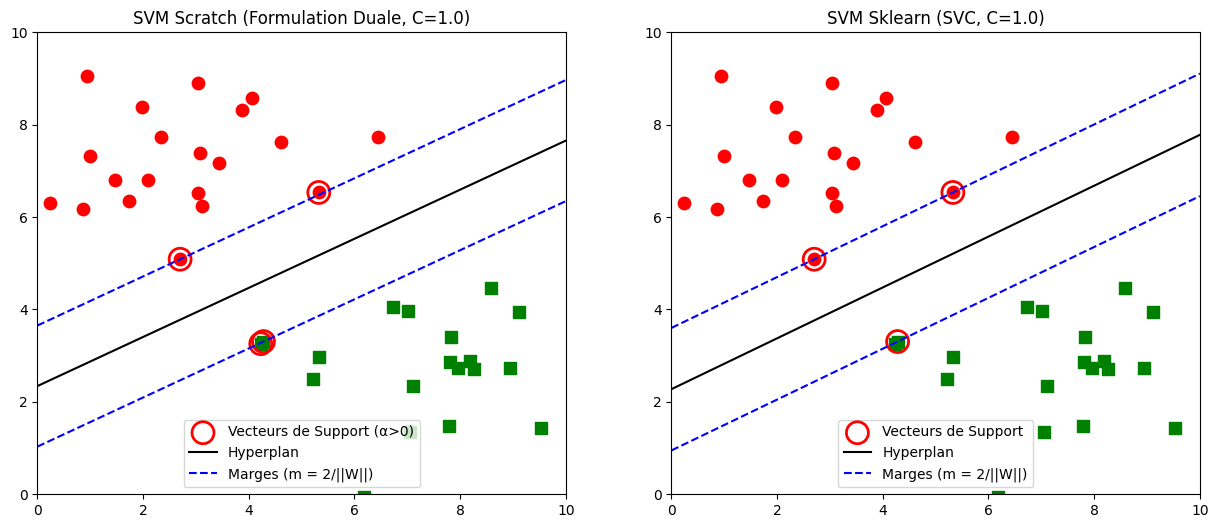

In [12]:
print("--- Comparaison des paramètres W et b ---")
print(f"Scratch : W = [{W_scratch[0]:.4f}, {W_scratch[1]:.4f}] | b = {b_scratch:.4f}")
print(f"Sklearn : W = [{W_sklearn[0]:.4f}, {W_sklearn[1]:.4f}] | b = {b_sklearn:.4f}")


import matplotlib.pyplot as plt

def tracer_hyperplan_et_marges(W, b, ax):
    # Tracé de la ligne Wx + b = 0 et des marges Wx + b = 1 et -1
    x_val = np.linspace(0, 10, 100)
    y_hyperplan = -(W[0] / W[1]) * x_val - (b / W[1])
    y_marge_1 = -(W[0] / W[1]) * x_val - ((b - 1) / W[1])
    y_marge_moins_1 = -(W[0] / W[1]) * x_val - ((b + 1) / W[1])
    
    ax.plot(x_val, y_hyperplan, color='black', linestyle='-', label='Hyperplan')
    ax.plot(x_val, y_marge_1, color='blue', linestyle='--', label='Marges (m = 2/||W||)')
    ax.plot(x_val, y_marge_moins_1, color='blue', linestyle='--')

plt.figure(figsize=(15, 6))

# Graphique Scratch 
ax1 = plt.subplot(1, 2, 1)

# On trace tous les points
ax1.scatter(X_A[:, 0], X_A[:, 1], color='r', marker='o', s=80)
ax1.scatter(X_B[:, 0], X_B[:, 1], color='g', marker='s', s=80)

# On entoure LES VECTEURS DE SUPPORT (ceux avec alpha > 0)
vecteurs_support_scratch = X_data_svm[vs_scratch_idx]
ax1.scatter(vecteurs_support_scratch[:, 0], vecteurs_support_scratch[:, 1], s=250, facecolors='none', edgecolors='red', linewidth=2, label='Vecteurs de Support (α>0)')

tracer_hyperplan_et_marges(W_scratch, b_scratch, ax1)
ax1.set_title(f'SVM Scratch (Formulation Duale, C={C_param})')
ax1.set_xlim(0, 10); ax1.set_ylim(0, 10)
ax1.legend()


# Graphique Sklearn
ax2 = plt.subplot(1, 2, 2)

ax2.scatter(X_A[:, 0], X_A[:, 1], color='r', marker='o', s=80)
ax2.scatter(X_B[:, 0], X_B[:, 1], color='g', marker='s', s=80)

# On entoure LES VECTEURS DE SUPPORT de Sklearn
vecteurs_support_sklearn = X_data_svm[vs_sklearn_idx]
ax2.scatter(vecteurs_support_sklearn[:, 0], vecteurs_support_sklearn[:, 1], s=250, facecolors='none', edgecolors='red', linewidth=2, label='Vecteurs de Support')

tracer_hyperplan_et_marges(W_sklearn, b_sklearn, ax2)
ax2.set_title(f'SVM Sklearn (SVC, C={C_param})')
ax2.set_xlim(0, 10); ax2.set_ylim(0, 10)
ax2.legend()

plt.show()